# Modelo: Gemma-4-12B.it

A continuación, mostramos el procedimiento realizado para evaluar las técnicas de *Zero-shot* y *Few Shot* para el conjunto de datos **Financial Phrase Bank** utilizando el modelo Gema-4-12B.it

In [1]:
!pip install -q transformers accelerate bitsandbytes datasets scikit-learn torch huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00


In [6]:
# importamos el conjunto de datos
import pandas as pd

data = pd.read_csv('Sentences_AllAgree.csv')
print(f"Datos insertados, tamaño de df: {df.shape}")
data.head()

Datos insertados, tamaño de df: (2264, 2)


,sentences,labels
0,"According to Gran , the company has no plans t...",1
1,"For the last quarter of 2010 , Componenta 's n...",2
2,"In the third quarter of 2010 , net sales incre...",2
3,Operating profit rose to EUR 13.1 mn from EUR ...,2
4,"Operating profit totalled EUR 21.1 mn , up fro...",2


In [3]:
from transformers import AutoProcessor, AutoModelForMultimodalLM
from huggingface_hub import login
from google.colab import userdata
import time

# importamos claves para tener mejores limites
hf_token = userdata.get('hf_token')
login(token=hf_token)

MODEL_ID = "google/gemma-4-12B-it"

# Cargamos el modelo
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.5k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/23.9G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

In [ ]:
def clean_pipeline_prediction(output_list):
    """Extracts and cleans the sentiment from the pipeline output."""
    if output_list and len(output_list) > 0 and 'generated_text' in output_list[0]:
        assistant_response = output_list[0]['generated_text'][-1]
        if 'content' in assistant_response:
            response_text = assistant_response['content'].lower().strip()
            if 'positive' in response_text:
                return 'positive'
            elif 'negative' in response_text:
                return 'negative'
            elif 'neutral' in response_text:
                return 'neutral'
    return 'unknown'

In [ ]:
positive_example = data[data['labels'] == 2].iloc[0]
neutral_example = data[data['labels'] == 1].iloc[0]
negative_example = data[data['labels'] == 0].iloc[0]

few_shot_examples = [
    {
        "role": "user",
        "content": f"Sentence: {positive_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "positive"},
    {
        "role": "user",
        "content": f"Sentence: {neutral_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "neutral"},
    {
        "role": "user",
        "content": f"Sentence: {negative_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "negative"}
]

In [6]:
# Procesamos la entrada al modelo
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    add_generation_prompt=True,
    enable_thinking=False
).to(model.device)
input_len = inputs["input_ids"].shape[-1]

# Generamos la salida
outputs = model.generate(**inputs, max_new_tokens=5)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

# Unimos la salida
final_output = processor.parse_response(response)


In [ ]:
# Generamos la lista para guardar las predicciones
gemma_predictions = []
total_sentences = len(data['sentences'])

for i, sentence in enumerate(data['sentences']):
    messages_for_sentence = [
        {"role": "system", "content": "You're an expert financial sentiment analyst, and you make no mistakes on your choices. Also you only answer with positive, negative or neutral"}]+ few_shot_examples + [{"role": "user", "content": f"Sentence: {{{sentence}}} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"}
    ]

    inputs = processor.apply_chat_template(
        messages_for_sentence,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
        enable_thinking=False
    ).to(model.device)
    input_len = inputs["input_ids"].shape[-1]

    outputs = model.generate(**inputs, max_new_tokens=5)
    response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

    final_output = processor.parse_response(response)
    gemma_predictions.append(final_output['content'])

    time.sleep(10)

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{total_sentences} sentences.")

print("Finished processing all sentences. First 5 predictions:")
print(gemma_predictions[:5])

In [ ]:
# Convertimos la lista de predicciones en csv
predictions_df = pd.DataFrame(gemma_predictions, columns=['Sentimiento (Sentiment)'])

# Guardamos CSV
predictions_df.to_csv('Resultados_gemma_oneshot - Hoja 1.csv', index=False)

print("Predictions saved to 'Resultados_gemma_oneshot - Hoja 1.csv'.")
print(predictions_df.head())

A continuación realizamos la evaluación de nuestro modelo

In [71]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score as f1_score_func, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df_real = pd.read_csv('Sentences_AllAgree.csv')
df_predicted = pd.read_csv('Resultados_gemma_fewshot.csv')

In [73]:
print(df_real.shape)
df_real.head(10)

(2264, 2)


,sentences,labels
0,"According to Gran , the company has no plans t...",1
1,"For the last quarter of 2010 , Componenta 's n...",2
2,"In the third quarter of 2010 , net sales incre...",2
3,Operating profit rose to EUR 13.1 mn from EUR ...,2
4,"Operating profit totalled EUR 21.1 mn , up fro...",2
5,Finnish Talentum reports its operating profit ...,2
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,2
7,Consolidated net sales increased 16 % to reach...,2
8,Foundries division reports its sales increased...,2
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",2


In [74]:
print(df_predicted.shape)
df_predicted.head(10)

(809, 2)


,Enunciado (Sentences),Sentimiento (Sentiment)
0,"According to Gran, the company has no plans to...",neutral
1,"For the last quarter of 2010, Componenta 's ne...",positive
2,"In the third quarter of 2010, net sales increa...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn, up from...",positive
5,Finnish Talentum reports its operating profit ...,positive
6,Clothing retail chain Sepp+ñl+ 's sales increa...,positive
7,Consolidated net sales increased 16% to reach ...,positive
8,Foundries division reports its sales increased...,positive
9,"HELSINKI (AFX) Shares closed higher, led by No...",positive


In [75]:
df_merged = pd.merge(df_real, df_predicted, left_index=True, right_index = True)
df_merged.head(10)

,sentences,labels,Enunciado (Sentences),Sentimiento (Sentiment)
0,"According to Gran , the company has no plans t...",1,"According to Gran, the company has no plans to...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",2,"For the last quarter of 2010, Componenta 's ne...",positive
2,"In the third quarter of 2010 , net sales incre...",2,"In the third quarter of 2010, net sales increa...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,2,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",2,"Operating profit totalled EUR 21.1 mn, up from...",positive
5,Finnish Talentum reports its operating profit ...,2,Finnish Talentum reports its operating profit ...,positive
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,2,Clothing retail chain Sepp+ñl+ 's sales increa...,positive
7,Consolidated net sales increased 16 % to reach...,2,Consolidated net sales increased 16% to reach ...,positive
8,Foundries division reports its sales increased...,2,Foundries division reports its sales increased...,positive
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",2,"HELSINKI (AFX) Shares closed higher, led by No...",positive


In [76]:
# Realizamos un mapero de etiquetas
label_map = {
    "neutral" : 1,
    "positive": 2,
    "negative": 0
}
df_merged['Sentimiento (Sentiment)'] = df_merged['Sentimiento (Sentiment)'].map(label_map)

# Convertimos la columna a tipo entero
df_merged['Sentimiento (Sentiment)'] = df_merged['Sentimiento (Sentiment)'].astype(int)
df_merged.head()

,sentences,labels,Enunciado (Sentences),Sentimiento (Sentiment)
0,"According to Gran , the company has no plans t...",1,"According to Gran, the company has no plans to...",1
1,"For the last quarter of 2010 , Componenta 's n...",2,"For the last quarter of 2010, Componenta 's ne...",2
2,"In the third quarter of 2010 , net sales incre...",2,"In the third quarter of 2010, net sales increa...",2
3,Operating profit rose to EUR 13.1 mn from EUR ...,2,Operating profit rose to EUR 13.1 mn from EUR ...,2
4,"Operating profit totalled EUR 21.1 mn , up fro...",2,"Operating profit totalled EUR 21.1 mn, up from...",2


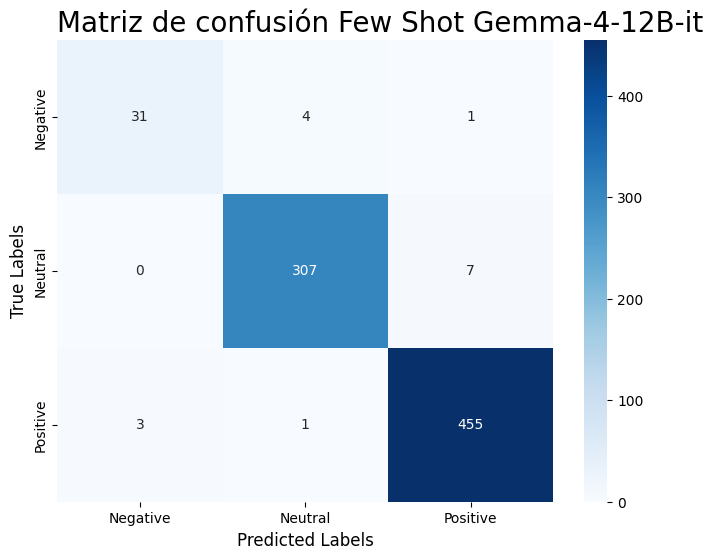

In [80]:
# Matriz de confusion
matriz_confusion = confusion_matrix(df_merged['Sentimiento (Sentiment)'], df_merged['labels'])

# Graficamos la matriz de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted Labels', fontsize = 12)
plt.ylabel('True Labels', fontsize = 12)
plt.title('Matriz de confusión Few Shot Gemma-4-12B-it', fontsize = 20, loc = 'left')
plt.show()

In [78]:
# Calculamos las metricas correspondientes
accuracy = accuracy_score(df_merged['Sentimiento (Sentiment)'], df_merged['labels'])
precision = precision_score(df_merged['Sentimiento (Sentiment)'], df_merged['labels'], average='weighted')
recall = recall_score(df_merged['Sentimiento (Sentiment)'], df_merged['labels'], average = 'micro')
f1 = f1_score_func(df_merged['Sentimiento (Sentiment)'], df_merged['labels'], average='micro')

In [79]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9802224969097652
Precision: 0.9800501762676832
Recall: 0.9802224969097652
F1 Score: 0.9802224969097652
